# Modelling Temporal Drift in Music Preferences using Emotion-Aware Sequential Representation Learning




## SECTION 1 — `config` (settings)


In [1]:
#  config 
DATA_PATH = "turkish_music_emotion_dataset.csv"  
RESULTS_DIR = "results"

SEED = 42

SEQ_LEN = 10
N_SEQUENCES = 800
K_NEIGHBORS = 8
JUMP_PROB = 0.2

LSTM_UNITS = 64
DENSE_UNITS = 32
TRANSFORMER_D_MODEL = 64
TRANSFORMER_NUM_HEADS = 4
TRANSFORMER_FF_DIM = 64

EPOCHS = 60
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
EARLY_STOP_PATIENCE = 8

TEST_SIZE = 0.30
VAL_TEST_SPLIT = 0.50

print("Config loaded.")

Config loaded.


## SECTION 2 — Imports


In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
)
from sklearn.metrics.pairwise import cosine_similarity

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("All imports OK.")

TensorFlow version: 2.16.2
All imports OK.


## SECTION 3 — `data_loader` (load + clean)

In [4]:
#  data_loader 
df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")

before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
df = df.dropna().reset_index(drop=True)
after = df.shape[0]
print(f"Cleaning: {before} -> {after} rows (removed {before - after})")

label_col = "Class"
feature_cols = [c for c in df.columns if c != label_col]

df.head()

Loaded dataset: 400 rows, 51 columns
Cleaning: 400 -> 388 rows (removed 12)


,Class,_RMSenergy_Mean,_Lowenergy_Mean,_Fluctuation_Mean,_Tempo_Mean,_MFCC_Mean_1,_MFCC_Mean_2,_MFCC_Mean_3,_MFCC_Mean_4,_MFCC_Mean_5,...,_Chromagram_Mean_9,_Chromagram_Mean_10,_Chromagram_Mean_11,_Chromagram_Mean_12,_HarmonicChangeDetectionFunction_Mean,_HarmonicChangeDetectionFunction_Std,_HarmonicChangeDetectionFunction_Slope,_HarmonicChangeDetectionFunction_PeriodFreq,_HarmonicChangeDetectionFunction_PeriodAmp,_HarmonicChangeDetectionFunction_PeriodEntropy
0,relax,0.052,0.591,9.136,130.043,3.997,0.363,0.887,0.078,0.221,...,0.426,1.000,0.008,0.101,0.316,0.261,0.018,1.035,0.593,0.970
1,relax,0.125,0.439,6.680,142.240,4.058,0.516,0.785,0.397,0.556,...,0.002,1.000,0.000,0.984,0.285,0.211,-0.082,3.364,0.702,0.967
2,relax,0.046,0.639,10.578,188.154,2.775,0.903,0.502,0.329,0.287,...,0.184,0.746,0.016,1.000,0.413,0.299,0.134,1.682,0.692,0.963
3,relax,0.135,0.603,10.442,65.991,2.841,1.552,0.612,0.351,0.011,...,0.038,1.000,0.161,0.757,0.422,0.265,0.042,0.354,0.743,0.968
4,relax,0.066,0.591,9.769,88.890,3.217,0.228,0.814,0.096,0.434,...,0.004,0.404,1.000,0.001,0.345,0.261,0.089,0.748,0.674,0.957


## SECTION 4 — `eda` (Emotional Feature Analysis)

Class
sad      98
relax    97
angry    97
happy    96
Name: count, dtype: int64


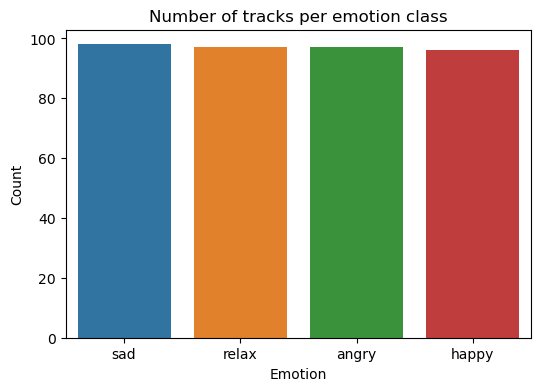

In [6]:
#  eda: class balance 
print(df[label_col].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(data=df, x=label_col, order=df[label_col].value_counts().index)
plt.title("Number of tracks per emotion class")
plt.xlabel("Emotion"); plt.ylabel("Count")
plt.show()

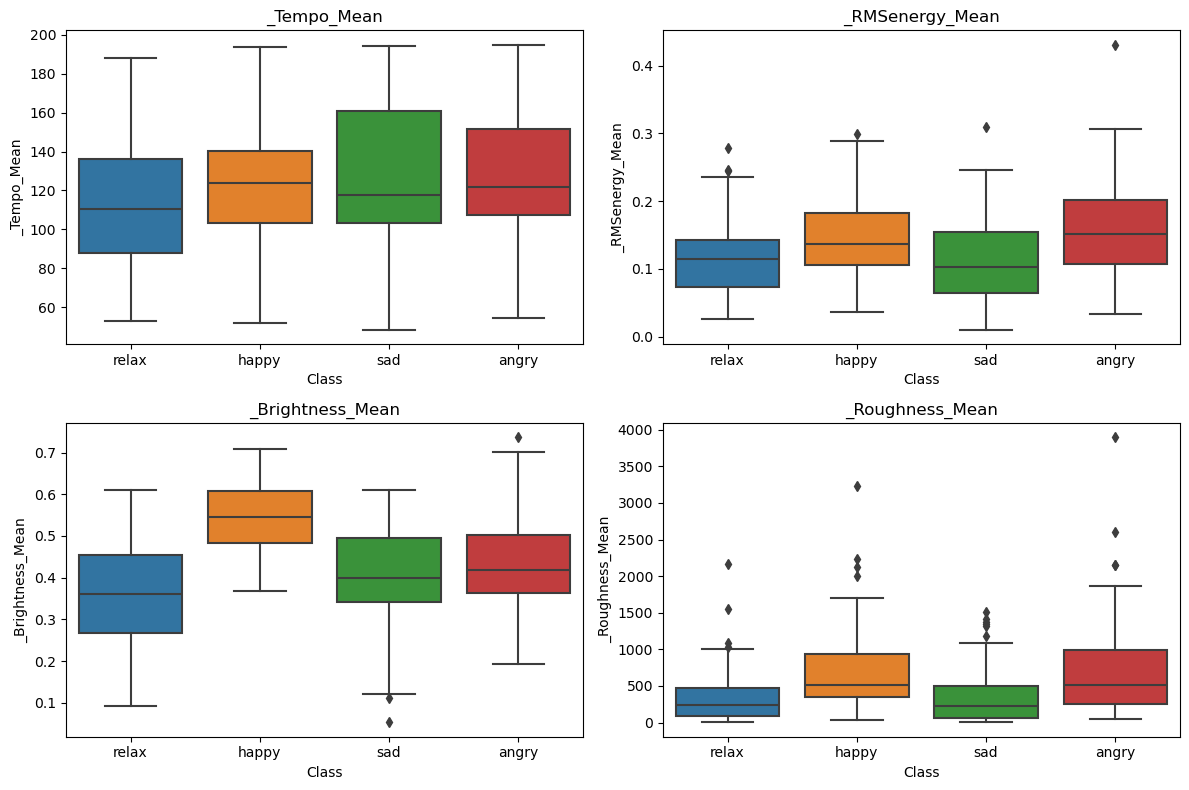

In [7]:
#  eda: feature distributions per emotion 
features_to_plot = ['_Tempo_Mean', '_RMSenergy_Mean', '_Brightness_Mean', '_Roughness_Mean']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.boxplot(data=df, x=label_col, y=feat, ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

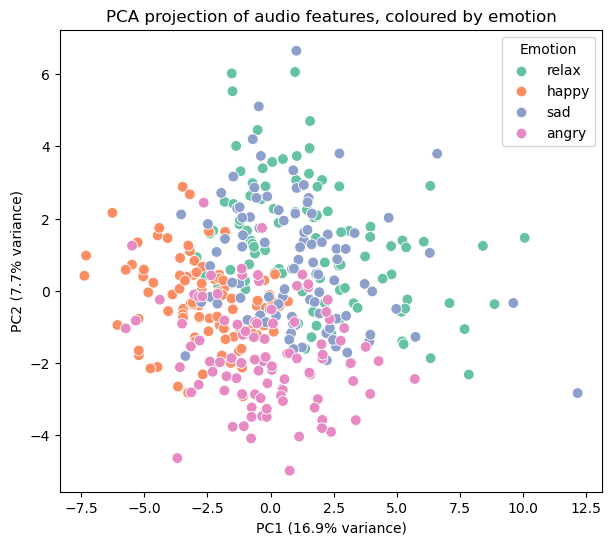

Explained variance by 2 PCs: 0.2455037240127526


In [8]:
#  eda: PCA projection 
X_raw = df[feature_cols].values
scaler_viz = StandardScaler()
X_scaled_viz = scaler_viz.fit_transform(X_raw)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_viz)

plt.figure(figsize=(7,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=df[label_col], palette='Set2', s=60)
plt.title("PCA projection of audio features, coloured by emotion")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend(title="Emotion")
plt.show()

print("Explained variance by 2 PCs:", pca.explained_variance_ratio_.sum())

## SECTION 5 — `preprocessing` (scaling + label encoding)

In [9]:
#  preprocessing 
X_raw2 = df[feature_cols].values
y_raw = df[label_col].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
print("Classes found:", list(label_encoder.classes_))

feature_scaler = StandardScaler()
X_scaled = feature_scaler.fit_transform(X_raw2)

print("X_scaled shape:", X_scaled.shape)
print("Sanity check -> mean of col 0:", round(X_scaled[:,0].mean(), 4),
      " std of col 0:", round(X_scaled[:,0].std(), 4))

Classes found: ['angry', 'happy', 'relax', 'sad']
X_scaled shape: (388, 50)
Sanity check -> mean of col 0: -0.0  std of col 0: 1.0


## SECTION 6 — `sequence_builder` (the key methodological step)



In [10]:
#  sequence_builder: Method A (random) 
def build_random_sequences(X, y, seq_len, n_sequences, seed=0):
    rng = np.random.default_rng(seed)
    seqs_X, seqs_y = [], []
    for _ in range(n_sequences):
        idx = rng.choice(len(X), size=seq_len, replace=False)
        seqs_X.append(X[idx])
        seqs_y.append(y[idx])
    return np.array(seqs_X), np.array(seqs_y)

X_seq_A, y_seq_A = build_random_sequences(X_scaled, y, SEQ_LEN, N_SEQUENCES, seed=SEED)
print("Method A shapes:", X_seq_A.shape, y_seq_A.shape)

Method A shapes: (800, 10, 50) (800, 10)


In [11]:
#  sequence_builder: Method B (similarity-chained) 
def _fit_nearest_neighbors(X, k):
    # algorithm="ball_tree" avoids the macOS OpenBLAS/threadpoolctl crash - keep this as is
    nn_model = NearestNeighbors(n_neighbors=k + 1, algorithm="ball_tree").fit(X)
    _, neighbor_idx = nn_model.kneighbors(X)
    return neighbor_idx

def build_chained_sequences(X, y, seq_len, n_sequences, k_neighbors=8, jump_prob=0.2, seed=0):
    neighbor_idx = _fit_nearest_neighbors(X, k_neighbors)
    rng = np.random.default_rng(seed)
    n = len(X)
    seqs_X, seqs_y = [], []
    for _ in range(n_sequences):
        current = rng.integers(0, n)
        chain = [current]
        for _ in range(seq_len - 1):
            if rng.random() < jump_prob:
                nxt = rng.integers(0, n)
            else:
                candidates = neighbor_idx[current][1:]
                nxt = rng.choice(candidates)
            chain.append(nxt)
            current = nxt
        seqs_X.append(X[chain])
        seqs_y.append(y[chain])
    return np.array(seqs_X), np.array(seqs_y)

X_seq_B, y_seq_B = build_chained_sequences(X_scaled, y, SEQ_LEN, N_SEQUENCES,
                                            k_neighbors=K_NEIGHBORS, jump_prob=JUMP_PROB, seed=SEED)
print("Method B shapes:", X_seq_B.shape, y_seq_B.shape)

# We use Method B (more realistic) going forward
X_seq, y_seq = X_seq_B, y_seq_B

Method B shapes: (800, 10, 50) (800, 10)


## SECTION 7 — `train` part 1: Train / Validation / Test split

In [12]:
#  train: split_sequences 
X_train, X_temp, y_train, y_temp = train_test_split(X_seq, y_seq, test_size=TEST_SIZE, random_state=SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=VAL_TEST_SPLIT, random_state=SEED)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape, y_val.shape)
print("Test: ", X_test.shape, y_test.shape)

N_FEATURES = X_train.shape[2]
N_CLASSES = len(label_encoder.classes_)
print("N_FEATURES:", N_FEATURES, " N_CLASSES:", N_CLASSES)

Train: (560, 10, 50) (560, 10)
Val:   (120, 10, 50) (120, 10)
Test:  (120, 10, 50) (120, 10)
N_FEATURES: 50  N_CLASSES: 4


## SECTION 8 — `models` part 1: LSTM + Attention

Plain-language reminder:
- **LSTM**: reads the sequence step by step, keeping a "memory" so it can relate earlier and later tracks.
- **Attention**: learns how much weight to give each step instead of treating every track equally.

In [13]:
#  models: build_lstm_attention_model 
def build_lstm_attention_model(seq_len, n_features, n_classes, lstm_units=64, dense_units=32):
    inputs = keras.Input(shape=(seq_len, n_features), name="sequence_input")

    x = layers.TimeDistributed(layers.Dense(dense_units, activation="relu"), name="feature_projection")(inputs)

    lstm_out = layers.Bidirectional(
        layers.LSTM(lstm_units, return_sequences=True), name="bilstm"
    )(x)

    attention_scores = layers.Dense(1, activation="tanh", name="attention_score")(lstm_out)
    attention_weights = layers.Softmax(axis=1, name="attention_weights")(attention_scores)
    context_vector = layers.Multiply(name="attention_context")([lstm_out, attention_weights])

    representation = layers.TimeDistributed(
        layers.Dense(dense_units, activation="relu"), name="dense_representation"
    )(context_vector)

    outputs = layers.TimeDistributed(
        layers.Dense(n_classes, activation="softmax"), name="prediction_output"
    )(representation)

    model = keras.Model(inputs=inputs, outputs=outputs, name="LSTM_Attention_EmotionSequenceModel")
    repr_model = keras.Model(inputs=inputs, outputs=[representation, attention_weights],
                              name="lstm_representation_extractor")
    return model, repr_model

lstm_model, lstm_repr_model = build_lstm_attention_model(SEQ_LEN, N_FEATURES, N_CLASSES, LSTM_UNITS, DENSE_UNITS)
lstm_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                    loss="sparse_categorical_crossentropy", metrics=["accuracy"])
lstm_model.summary()

Model: "LSTM_Attention_EmotionSequenceModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 10, 50)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 10, 32)    │      1,632 │ sequence_input[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm              │ (None, 10, 128)   │     49,664 │ feature_projecti… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_score     │ (None, 10, 1)     │        129 │ bilstm[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_weights   │ (None, 10, 1)     │          0 │ attention_score[… │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_context   │ (None, 10, 128)   │          0 │ bilstm[0][0],     │
│ (Multiply)          │                   │            │ attention_weight… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_representati… │ (None, 10, 32)    │      4,128 │ attention_contex… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_output   │ (None, 10, 4)     │        132 │ dense_representa… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 55,685 (217.52 KB)

 Trainable params: 55,685 (217.52 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
#  train: fit the LSTM model 
early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)

history_lstm = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9971 - loss: 0.0073 - val_accuracy: 0.9942 - val_loss: 0.0156
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0071 - val_accuracy: 0.9942 - val_loss: 0.0154
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9971 - loss: 0.0070 - val_accuracy: 0.9942 - val_loss: 0.0152
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0069 - val_accuracy: 0.9942 - val_loss: 0.0150
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0068 - val_accuracy: 0.9942 - val_loss: 0.0148
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0068 - val_accuracy: 0.9942 - val_loss: 0.0145
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0067 - val_accuracy: 0.9942 - val_loss: 0.0143
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9971 - loss: 0.0066 - val_accuracy: 0.9942 - val_los

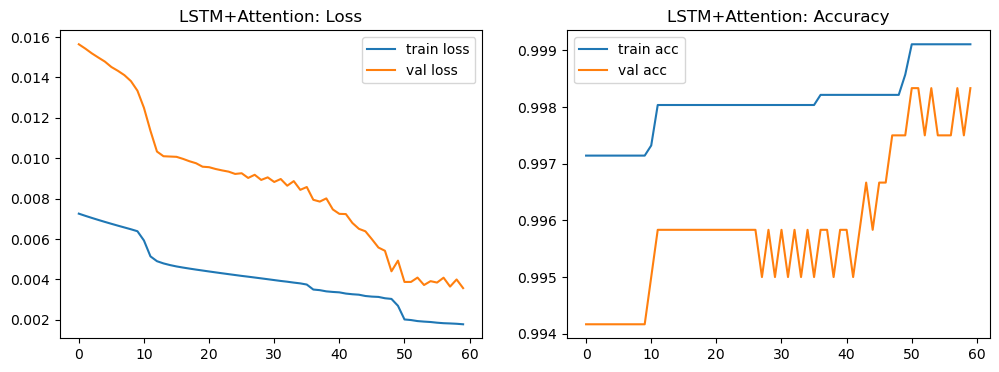

In [16]:
#  train: plot LSTM training curves 
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history_lstm.history['loss'], label='train loss')
axes[0].plot(history_lstm.history['val_loss'], label='val loss')
axes[0].set_title("LSTM+Attention: Loss"); axes[0].legend()

axes[1].plot(history_lstm.history['accuracy'], label='train acc')
axes[1].plot(history_lstm.history['val_accuracy'], label='val acc')
axes[1].set_title("LSTM+Attention: Accuracy"); axes[1].legend()
plt.show()

## SECTION 9 — `models` part 2: Transformer (for your LSTM-vs-Transformer comparison)

In [17]:
#  models: build_transformer_model 
def _transformer_encoder_block(x, head_size, num_heads, ff_dim, dropout=0.1):
    attn_out = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    out1 = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)

    ff_out = layers.Dense(ff_dim, activation="relu")(out1)
    ff_out = layers.Dense(x.shape[-1])(ff_out)
    ff_out = layers.Dropout(dropout)(ff_out)
    out2 = layers.LayerNormalization(epsilon=1e-6)(out1 + ff_out)
    return out2

def build_transformer_model(seq_len, n_features, n_classes, d_model=64, num_heads=4, ff_dim=64):
    inputs = keras.Input(shape=(seq_len, n_features), name="sequence_input")
    x = layers.TimeDistributed(layers.Dense(d_model, activation="relu"), name="feature_projection")(inputs)

    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_embedding_layer = layers.Embedding(input_dim=seq_len, output_dim=d_model)
    pos_encoding = pos_embedding_layer(positions)
    x = x + pos_encoding

    x = _transformer_encoder_block(x, head_size=d_model // num_heads, num_heads=num_heads, ff_dim=ff_dim)

    representation = layers.TimeDistributed(layers.Dense(32, activation="relu"), name="dense_representation")(x)
    outputs = layers.TimeDistributed(layers.Dense(n_classes, activation="softmax"), name="prediction_output")(representation)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Transformer_EmotionSequenceModel")
    repr_model = keras.Model(inputs=inputs, outputs=representation, name="transformer_representation_extractor")
    return model, repr_model

transformer_model, transformer_repr_model = build_transformer_model(
    SEQ_LEN, N_FEATURES, N_CLASSES, TRANSFORMER_D_MODEL, TRANSFORMER_NUM_HEADS, TRANSFORMER_FF_DIM
)
transformer_model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
                           loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transformer_model.summary()

Model: "Transformer_EmotionSequenceModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ sequence_input      │ (None, 10, 50)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_projection  │ (None, 10, 64)    │      3,264 │ sequence_input[0… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 64)    │          0 │ feature_projecti… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 10, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10, 64)    │      4,160 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 10, 64)    │      4,160 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 10, 64)    │          0 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 10, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_representati… │ (None, 10, 32)    │      2,080 │ layer_normalizat… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction_output   │ (None, 10, 4)     │        132 │ dense_representa… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 30,692 (119.89 KB)

 Trainable params: 30,692 (119.89 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
#  train: fit the Transformer model 
early_stop2 = keras.callbacks.EarlyStopping(monitor="val_loss", patience=EARLY_STOP_PATIENCE, restore_best_weights=True)

history_transformer = transformer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop2],
    verbose=1
)

Epoch 1/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0013 - val_accuracy: 0.9983 - val_loss: 0.0093
Epoch 2/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9983 - val_loss: 0.0091
Epoch 3/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9983 - val_loss: 0.0093
Epoch 4/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 8.9327e-04 - val_accuracy: 0.9983 - val_loss: 0.0093
Epoch 5/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 8.2884e-04 - val_accuracy: 0.9983 - val_loss: 0.0094
Epoch 6/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 7.3806e-04 - val_accuracy: 0.9983 - val_loss: 0.0091
Epoch 7/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 6.3130e-04 - val_accuracy: 0.9983 - val_loss: 0.0093
Epoch 8/60
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 6.4326e-04 - val_accurac

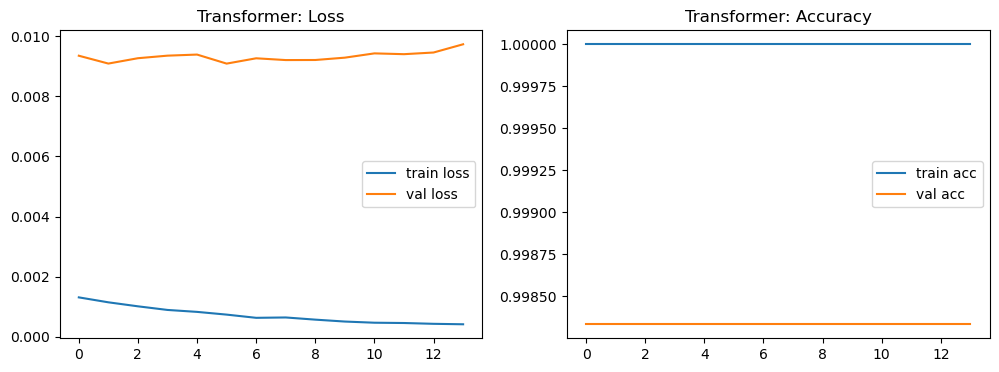

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history_transformer.history['loss'], label='train loss')
axes[0].plot(history_transformer.history['val_loss'], label='val loss')
axes[0].set_title("Transformer: Loss"); axes[0].legend()

axes[1].plot(history_transformer.history['accuracy'], label='train acc')
axes[1].plot(history_transformer.history['val_accuracy'], label='val acc')
axes[1].set_title("Transformer: Accuracy"); axes[1].legend()
plt.show()

## SECTION 10 — `evaluate` (accuracy / precision / recall / F1 + confusion matrix)

--- LSTM + Attention ---
Accuracy : 0.9992
Precision: 0.9989
Recall   : 0.9988
F1-score : 0.9988

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00       383
       happy       1.00      1.00      1.00       392
       relax       1.00      1.00      1.00       201
         sad       1.00      1.00      1.00       224

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



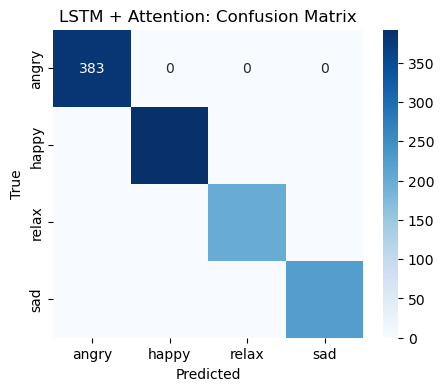

--- Transformer ---
Accuracy : 0.9992
Precision: 0.9989
Recall   : 0.9993
F1-score : 0.9991

              precision    recall  f1-score   support

       angry       1.00      1.00      1.00       383
       happy       1.00      1.00      1.00       392
       relax       1.00      1.00      1.00       201
         sad       1.00      1.00      1.00       224

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



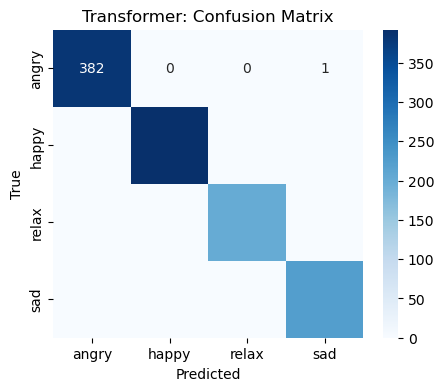

,model,accuracy,precision,recall,f1
0,LSTM + Attention,0.999167,0.998889,0.998756,0.998820
1,Transformer,0.999167,0.998889,0.999347,0.999116


In [21]:
#  evaluate 
def evaluate_model(model, X_test, y_test, label_encoder, name="Model"):
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=-1)

    y_true_flat = y_test.flatten()
    y_pred_flat = y_pred.flatten()

    acc = accuracy_score(y_true_flat, y_pred_flat)
    prec = precision_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)
    rec = recall_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)
    f1 = f1_score(y_true_flat, y_pred_flat, average="macro", zero_division=0)

    print(f"--- {name} ---")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}\n")
    print(classification_report(y_true_flat, y_pred_flat, target_names=label_encoder.classes_, zero_division=0))

    cm = confusion_matrix(y_true_flat, y_pred_flat)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"{name}: Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.show()

    return {"model": name, "accuracy": acc, "precision": prec, "recall": rec, "f1": f1}

results_lstm = evaluate_model(lstm_model, X_test, y_test, label_encoder, name="LSTM + Attention")
results_transformer = evaluate_model(transformer_model, X_test, y_test, label_encoder, name="Transformer")

comparison_df = pd.DataFrame([results_lstm, results_transformer])
comparison_df

## SECTION 11 — `drift_score` (Preference Drift Score)

`Drift(t) = 1 - cosine_similarity(representation_t, representation_(t-1))`. Near 0 = stable preference; near 1 = big emotional jump.

In [22]:
#  drift_score: compute 
def compute_preference_drift(repr_model, X_data, is_lstm=True):
    if is_lstm:
        representations, attn_weights = repr_model.predict(X_data, verbose=0)
    else:
        representations = repr_model.predict(X_data, verbose=0)
        attn_weights = None

    n_seq, seq_len, dim = representations.shape
    drift_scores = np.zeros((n_seq, seq_len - 1))

    for i in range(n_seq):
        for t in range(1, seq_len):
            r_prev = representations[i, t-1].reshape(1, -1)
            r_curr = representations[i, t].reshape(1, -1)
            sim = cosine_similarity(r_prev, r_curr)[0, 0]
            drift_scores[i, t-1] = 1 - sim

    return drift_scores, representations, attn_weights

drift_scores_test, reprs_test, attn_test = compute_preference_drift(lstm_repr_model, X_test, is_lstm=True)

print("Drift score matrix shape:", drift_scores_test.shape)
print("Average Preference Drift Score across all test sequences:", drift_scores_test.mean())

Drift score matrix shape: (120, 9)
Average Preference Drift Score across all test sequences: 0.2132714071897445


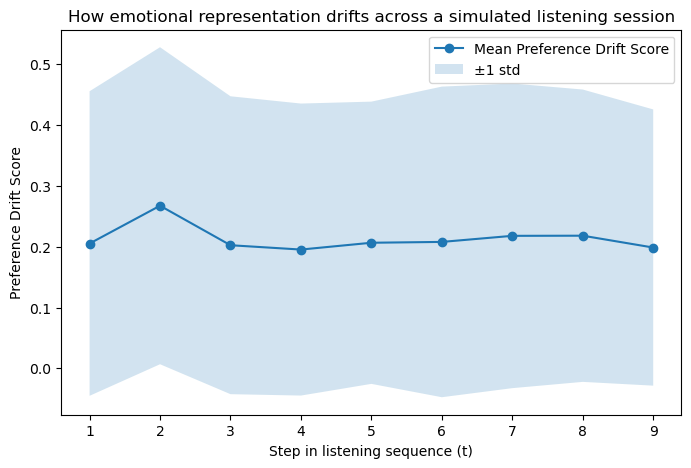

In [23]:
#  drift_score: plot mean drift across the session 
mean_drift = drift_scores_test.mean(axis=0)
std_drift = drift_scores_test.std(axis=0)
steps = np.arange(1, SEQ_LEN)

plt.figure(figsize=(8,5))
plt.plot(steps, mean_drift, marker='o', label="Mean Preference Drift Score")
plt.fill_between(steps, mean_drift - std_drift, mean_drift + std_drift, alpha=0.2, label="±1 std")
plt.xlabel("Step in listening sequence (t)")
plt.ylabel("Preference Drift Score")
plt.title("How emotional representation drifts across a simulated listening session")
plt.legend()
plt.show()

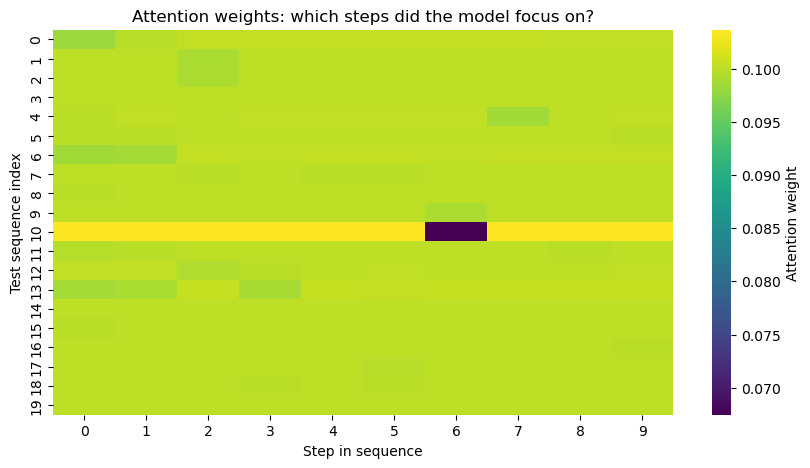

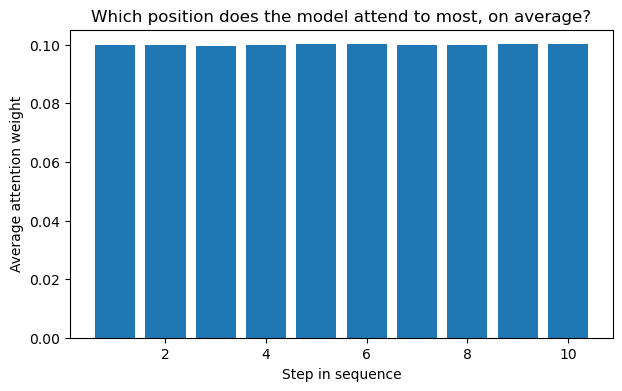

In [24]:
# drift_score: attention heatmap 
attn_weights_flat = attn_test.squeeze(-1)

plt.figure(figsize=(10,5))
sns.heatmap(attn_weights_flat[:20], cmap="viridis", cbar_kws={'label': 'Attention weight'})
plt.xlabel("Step in sequence"); plt.ylabel("Test sequence index")
plt.title("Attention weights: which steps did the model focus on?")
plt.show()

plt.figure(figsize=(7,4))
plt.bar(range(1, SEQ_LEN+1), attn_weights_flat.mean(axis=0))
plt.xlabel("Step in sequence"); plt.ylabel("Average attention weight")
plt.title("Which position does the model attend to most, on average?")
plt.show()

Mean drift WHEN emotion label changes : 0.4380
Mean drift WHEN emotion label stays same: 0.0084


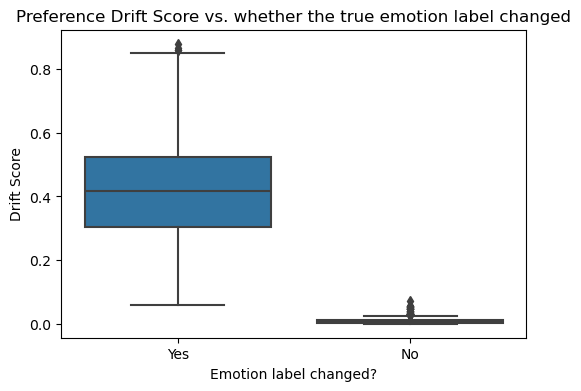

In [25]:
# drift_score: validity check (drift vs true label change) 
label_changed = (y_test[:, 1:] != y_test[:, :-1]).astype(int)

drift_when_changed = drift_scores_test[label_changed == 1]
drift_when_same    = drift_scores_test[label_changed == 0]

print(f"Mean drift WHEN emotion label changes : {drift_when_changed.mean():.4f}")
print(f"Mean drift WHEN emotion label stays same: {drift_when_same.mean():.4f}")

plt.figure(figsize=(6,4))
sns.boxplot(data=pd.DataFrame({
    "Drift Score": np.concatenate([drift_when_changed, drift_when_same]),
    "Emotion label changed?": ["Yes"]*len(drift_when_changed) + ["No"]*len(drift_when_same)
}), x="Emotion label changed?", y="Drift Score")
plt.title("Preference Drift Score vs. whether the true emotion label changed")
plt.show()

## SECTION 12 — Save everything for your dissertation

In [26]:
os.makedirs(RESULTS_DIR, exist_ok=True)

lstm_model.save(f"{RESULTS_DIR}/lstm_attention_model.keras")
transformer_model.save(f"{RESULTS_DIR}/transformer_model.keras")
comparison_df.to_csv(f"{RESULTS_DIR}/model_comparison.csv", index=False)
np.save(f"{RESULTS_DIR}/drift_scores_test.npy", drift_scores_test)

print("Saved everything to:", RESULTS_DIR)
print(comparison_df)

Saved everything to: results
              model  accuracy  precision    recall        f1
0  LSTM + Attention  0.999167   0.998889  0.998756  0.998820
1       Transformer  0.999167   0.998889  0.999347  0.999116
